In [ ]:
import pandas as pd

dbs = ['Benler', 'CHVD', 'DEVoC', 'EarlyVir', 'GPD', 'GVD', 'IMGVR', 'J4D', 'MGV', 'RefSeq_Viral', 'CHGV']

df = pd.read_excel('../data/Supplementary_Data_1_vOTU_metadata.xlsx', usecols=['votu_id'] + dbs + ['novel'])

"Comparison of the assembled vOTUs with 11 of the largest and most widely used viral genomic databases highlighted significant novelty (**>62% novel**)"

In [2]:
df.novel.sum()/len(df)*100

np.float64(62.976073418551294)

"The largest individual overlaps were with IMG/VR (**32%**) and GPD (**22%**), while the overlap with other gut phage databases typically accounted for **<10%** of the vOTUs assembled."

In [3]:
percent_per_db = df[dbs].mean()*100

In [4]:
percent_per_db.sort_values(ascending=False)

IMGVR           31.556867
GPD             21.668305
MGV             18.341527
CHVD            12.025565
GVD              9.488692
CHGV             5.850541
EarlyVir         5.001639
J4D              4.470665
Benler           3.287447
DEVoC            1.550311
RefSeq_Viral     0.494920
dtype: float64

### Fig. 1C: UpSet plot of vOTU novelty

In [6]:
replacements = {'Benler': 'Benler et al.', 'EarlyVir': 'Shah et al.', 'IMGVR': 'IMG/VR v4', 'J4D': 'Nishijima et al.', 'RefSeq_Viral': 'RefSeq Viral'}
df = df.rename(columns=replacements)

dbs1 = [replacements.get(db, db) for db in dbs]

votu_in_db = dict()
for db in dbs1 + ['novel']:
    votu_in_db[db] = df.loc[df[db] == 1].votu_id.tolist()

c:\Users\chenhr\AppData\Local\Programs\Python\Python310\lib\site-packages\upsetplot\data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
c:\Users\chenhr\AppData\Local\Programs\Python\Python310\lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original obj

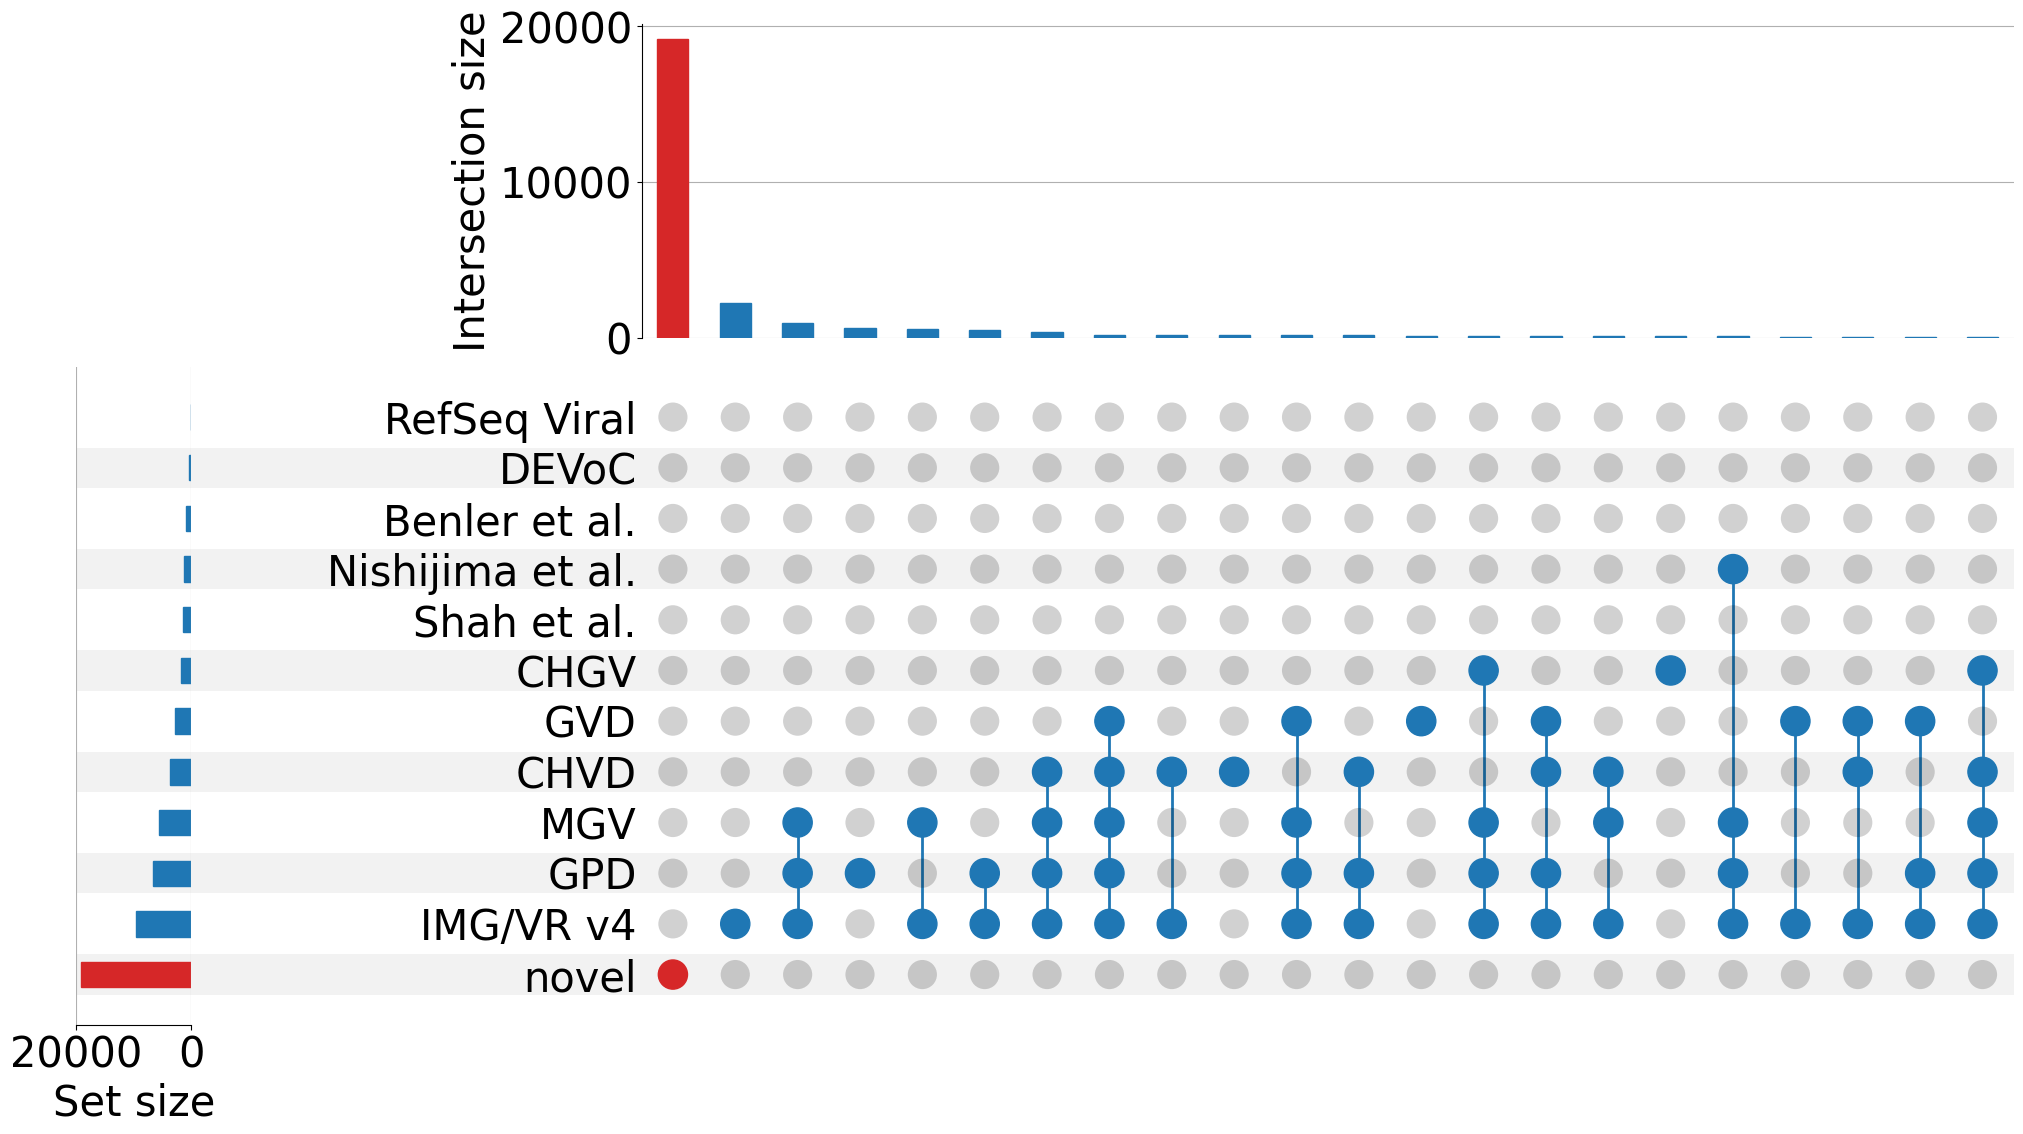

In [8]:
from upsetplot import from_contents, UpSet
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams["font.size"] = 30

novelty = from_contents(votu_in_db)
upset = UpSet(novelty, subset_size="count", sort_by="cardinality", element_size=60,
              min_subset_size=100
              )

upset.style_subsets(present=['novel'], facecolor='C3')
upset.style_subsets(absent=['novel'], facecolor='C0')

upset.style_categories(['novel'], bar_facecolor='C3')
upset.style_categories(dbs1, bar_facecolor='C0')

fig = plt.figure()
pp = upset.plot(fig=fig)
fig.set_size_inches(25,13)

pp['totals'].set_xticks([0,20000])
pp['totals'].set_xlabel("Set size")

plt.show()